In [ ]:
import duckdb
path = "/home/juelg/code/duobench/robot-control-stack/bin_sortv2"
duckdb.sql(f"describe select *, unnest(obs) from read_parquet('{path}')"), duckdb.sql(f"select count(*) as n_frames from read_parquet('{path}')")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 103.8 MB/s eta 0:00:0000:01


(┌─────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [12]:
import duckdb

path = "/home/juelg/code/duobench/robot-control-stack/bin_sortv2"

# Pull only the single latest record
query = f"""
    SELECT uuid, timestamp 
    FROM read_parquet('{path}') 
    ORDER BY timestamp DESC 
    LIMIT 1
"""

# Fetch as a standard Python tuple: (uuid, timestamp)
latest_record = duckdb.sql(query).fetchone()

print("Latest Episode UUID and Timestamp:", latest_record)

Latest Episode UUID and Timestamp: ('5f3c0399f9544621ba6caca3363635e8', 1779292467.945553)


In [13]:
import duckdb

path = "/home/juelg/code/duobench/robot-control-stack/bin_sortv2"
path2 = "/home/juelg/code/duobench/robot-control-stack/bin_sortv3"
target_uuid = "5f3c0399f9544621ba6caca3363635e8"

# SQL to select all data, but override 'success' for the specific UUID
query = f"""
    SELECT 
        * EXCLUDE (success), 
        CASE 
            WHEN uuid = '{target_uuid}' THEN false 
            ELSE success 
        END AS success
    FROM read_parquet('{path}')
"""

# Execute and load into a Pandas DataFrame
df = duckdb.sql(query).df()

# Overwrite the original Parquet file with the updated data
df.to_parquet(path2)

print(f"Successfully set 'success' to False for UUID: {target_uuid}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Successfully set 'success' to False for UUID: 5f3c0399f9544621ba6caca3363635e8


In [4]:
duckdb.sql(
f"""SELECT 
    info
FROM read_parquet('{path}')
WHERE success
limit 1
    """
)

┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                                                                                                                                                                                                                                                                                                 info                         

In [19]:
duckdb.sql(
    "SELECT DISTINCT uuid as successful "
    f"FROM read_parquet('{path}') "
    "WHERE success ORDER BY uuid"
)

┌──────────────────────────────────┐
│            successful            │
│             varchar              │
├──────────────────────────────────┤
│ 0e61faf0c4d147938802da6f285cc053 │
│ 56626f8b6c5d4e73bd6efd911aea68c0 │
│ 7c5e7de2d7aa4db8b361ec5b22499c6b │
│ 87901475844a441395b3c7d51d82c1de │
└──────────────────────────────────┘

In [25]:
import duckdb
import os

# --- Configuration Variables ---
directory_path = "/home/juelg/code/duobench/robot-control-stack/ball_maze"
file_name = "2026-05-12_part-0.parquet"
target_uuid = "7c5e7de2d7aa4db8b361ec5b22499c6b"

# Construct the full paths
file_path = os.path.join(directory_path, file_name)
temp_path = file_path + ".tmp"

# --- Database Operations ---
con = duckdb.connect()

print(f"Reading data from {file_path}...")
# 1. Load the Parquet data from the specific file
con.execute(f"CREATE TABLE dataset AS SELECT * FROM read_parquet('{file_path}')")

print(f"Updating 'success' to false for UUID: {target_uuid}...")
# 2. Execute the update
con.execute("UPDATE dataset SET success = false WHERE uuid = ?", (target_uuid,))

print("Writing to temporary file...")
# 3. Write the modified table back to a temporary file inside the directory
con.execute(f"COPY dataset TO '{temp_path}' (FORMAT PARQUET)")

# Close the database connection before manipulating files
con.close()

print("Overwriting the original file...")
# 4. Safely replace the exact file, leaving the directory intact
os.replace(temp_path, file_path)

print("Done! Directory structure is preserved.")

Reading data from /home/juelg/code/duobench/robot-control-stack/ball_maze/2026-05-12_part-0.parquet...
Updating 'success' to false for UUID: 7c5e7de2d7aa4db8b361ec5b22499c6b...
Writing to temporary file...
Overwriting the original file...
Done! Directory structure is preserved.


In [3]:
duckdb.sql(
    "SELECT count(DISTINCT uuid) as successful "
    f"FROM read_parquet('{path}') "
    "WHERE success"
),duckdb.sql(
    "SELECT count(DISTINCT uuid) as n_episodes "
    f"FROM read_parquet('{path}') "
)

(┌────────────┐
 │ successful │
 │   int64    │
 ├────────────┤
 │        113 │
 └────────────┘,
 ┌────────────┐
 │ n_episodes │
 │   int64    │
 ├────────────┤
 │        115 │
 └────────────┘)

In [84]:
duckdb.sql(
f"""SELECT 
    MAX(step)/30, MIN(step)/30, AVG(step)/30
FROM read_parquet('{path}')
WHERE success
    """
)


┌────────────────────┬───────────────────┬───────────────────┐
│  (max(step) / 30)  │ (min(step) / 30)  │ (avg(step) / 30)  │
│       double       │      double       │      double       │
├────────────────────┼───────────────────┼───────────────────┤
│ 19.533333333333335 │ 8.533333333333333 │ 11.66923076923077 │
└────────────────────┴───────────────────┴───────────────────┘

episode uuid: 7c5e7de2d7aa4db8b361ec5b22499c6b, success: False, n_steps: 844, info: {'left': {'platform': 'hardware', 'absolute_action': [0.5092409253120422, 0.2895634174346924, 0.16640011966228485, 0.8264918230390301, 0.3795456871273817, 0.1573973020068592, -0.3848147959130286], 'terminated': False, 'truncated': False}, 'right': {'platform': 'hardware', 'absolute_action': [0.46342507004737854, -0.32870620489120483, 0.1969984769821167, 0.8623926086992065, -0.3068727980040084, 0.05247313104626525, 0.3991924909418636], 'terminated': False, 'truncated': False}, 'camera_available': True, 'frame_timestamp': 1778597070.9116964}


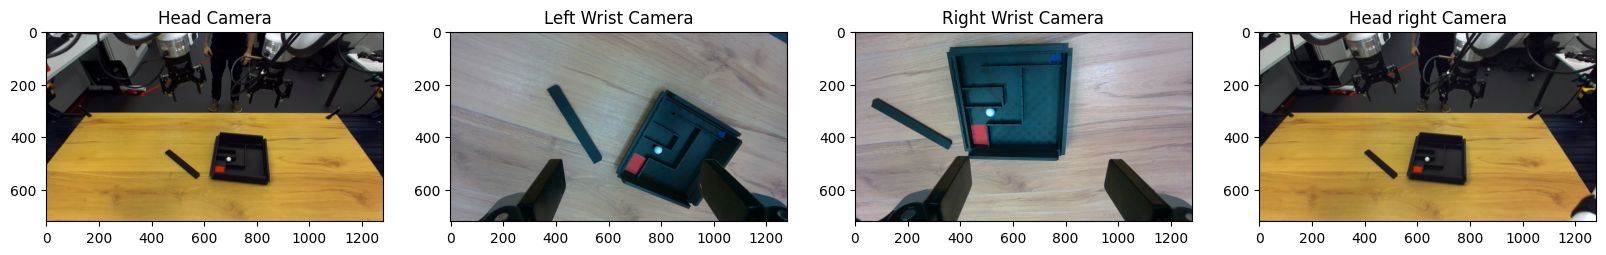

In [20]:
import io
from matplotlib import pyplot as plt
from PIL import Image
import duckdb
episode = 2
step = 800


uuids = duckdb.sql(f"SELECT DISTINCT uuid FROM read_parquet('{path}') WHERE success ORDER BY uuid").fetchnumpy()
# uuids
uuid1 = uuids["uuid"][episode]
rel = duckdb.read_parquet(path)
success = rel.filter(f"uuid='{uuid1}' and step={step}").select("success").fetchone()[0]
info = rel.filter(f"uuid='{uuid1}' and step={step}").select("info").fetchone()[0]
count = rel.filter(f"uuid='{uuid1}'").count("*").fetchone()[0]
print(f"episode uuid: {uuid1}, success: {success}, n_steps: {count}, info: {info}")



# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 4, figsize=(20, 5))


img1_data = rel.filter(f"uuid='{uuid1}' and step={step}").select("obs.frames.head.rgb.data").fetchone()[0]
image1 = Image.open(io.BytesIO(img1_data))
ax[0].imshow(image1)
ax[0].set_title("Head Camera")


img2_data = rel.filter(f"uuid='{uuid1}' and step={step}").select("obs.frames.left_wrist.rgb.data").fetchone()[0]
image2 = Image.open(io.BytesIO(img2_data))
ax[1].imshow(image2)
ax[1].set_title("Left Wrist Camera") # Optional title

img3_data = rel.filter(f"uuid='{uuid1}' and step={step}").select("obs.frames.right_wrist.rgb.data").fetchone()[0]
image3 = Image.open(io.BytesIO(img3_data))
ax[2].imshow(image3)
ax[2].set_title("Right Wrist Camera") # Optional title

img1_data = rel.filter(f"uuid='{uuid1}' and step={step}").select("obs.frames.head_right.rgb.data").fetchone()[0]
image1 = Image.open(io.BytesIO(img1_data))
ax[3].imshow(image1)
ax[3].set_title("Head right Camera")



plt.show()

In [96]:
import duckdb
import io
import matplotlib.pyplot as plt
from PIL import Image

# Define the path to your parquet file(s)

# SQL query to get the first step of the first episode
query = f"""
WITH first_episode AS (
    -- Identify the first episode (uuid) by taking the earliest timestamp
    SELECT uuid
    FROM read_parquet('{path}')
    ORDER BY "timestamp" ASC
    LIMIT 1
)
SELECT 
    obs.frames.left_wrist.depth.data AS left_wrist_blob,
    obs.frames.right_wrist.depth.data AS right_wrist_blob,
    obs.frames.head.depth.data AS head_blob
FROM read_parquet('{path}')
WHERE uuid = (SELECT uuid FROM first_episode)
ORDER BY step ASC
LIMIT 1;
"""

# Execute the query and fetch the single row
row = duckdb.sql(query).fetchone()

# Extract the BLOBs (returned as Python bytes)
left_wrist_blob, right_wrist_blob, head_blob = row

# Convert bytes to PIL Images
img_left = Image.open(io.BytesIO(left_wrist_blob))
img_right = Image.open(io.BytesIO(right_wrist_blob))
img_head = Image.open(io.BytesIO(head_blob))

# Plot the frames side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_left)
axes[0].set_title("Left Wrist Frame")
axes[0].axis("off")

axes[1].imshow(img_right)
axes[1].set_title("Right Wrist Frame")
axes[1].axis("off")

axes[2].imshow(img_head)
axes[2].set_title("Head Frame")
axes[2].axis("off")

plt.tight_layout()
plt.show()

BinderException: Binder Error: Could not find key "depth" in struct

Candidate Entries: "rgb"

In [38]:
duckdb.sql(
f"""SELECT 
    timestamp
FROM read_parquet('{path}')
    """
)

┌───────────────────┐
│     timestamp     │
│      double       │
├───────────────────┤
│ 1777976566.764664 │
│ 1777976566.796761 │
│ 1777976566.828648 │
│ 1777976566.861564 │
│ 1777976566.892437 │
│ 1777976566.925095 │
│ 1777976566.973188 │
│ 1777976567.004589 │
│ 1777976567.037067 │
│ 1777976567.070343 │
│         ·         │
│         ·         │
│         ·         │
│ 1777976516.320072 │
│ 1777976516.370078 │
│ 1777976516.400288 │
│ 1777976516.433601 │
│ 1777976516.464637 │
│ 1777976516.496684 │
│ 1777976516.530015 │
│ 1777976516.560782 │
│ 1777976516.593983 │
│ 1777976516.624152 │
└───────────────────┘
      1108 rows    
     (20 shown)     

In [199]:
path = "/home/juelg/code/duobench/robot-control-stack/real_bin_sort_test2_new2_without_nogrp"
# path = "/home/juelg/code/duobench/robot-control-stack/real_bin_sort_test2_new_without_nogrp"
# path = "/home/juelg/code/duobench/robot-control-stack/real_bin_sort_test2_old_without_nogrp"

In [8]:
duckdb.sql(
f"""WITH episode_stats AS (
    SELECT
        uuid,
        COUNT(*) AS frame_count,
        MAX("timestamp") - MIN("timestamp") AS duration_seconds
    FROM read_parquet('{path}')
    GROUP BY uuid
    HAVING duration_seconds > 0 -- Prevents division by zero for single-frame episodes
)
SELECT 
    AVG(frame_count / duration_seconds) AS average_frequency_hz
FROM episode_stats;
"""
)

┌──────────────────────┐
│ average_frequency_hz │
│        double        │
├──────────────────────┤
│   22.238600508286407 │
└──────────────────────┘

In [6]:
duckdb.sql(
f"""WITH episode_stats AS (
    SELECT
        uuid,
        COUNT(*) AS frame_count,
        MAX("timestamp") - MIN("timestamp") AS duration_seconds
    FROM read_parquet('{path}')
    GROUP BY uuid
    HAVING duration_seconds > 0 -- Prevents division by zero for single-frame episodes
)
SELECT 
    STDDEV(frame_count / duration_seconds) AS std_frequency_hz
FROM episode_stats;
"""
)

┌──────────────────┐
│ std_frequency_hz │
│      double      │
├──────────────────┤
│             NULL │
└──────────────────┘

In [7]:
duckdb.sql(
f"""WITH frame_intervals AS (
    SELECT 
        uuid,
        "timestamp",
        -- Get the timestamp of the *next* frame within the same episode
        LEAD("timestamp") OVER (PARTITION BY uuid ORDER BY "timestamp") AS next_timestamp
    FROM read_parquet('{path}')
),
instantaneous_frequencies AS (
    SELECT
        -- Frequency = 1 / time_difference
        1.0 / (next_timestamp - "timestamp") AS freq_hz
    FROM frame_intervals
    WHERE next_timestamp IS NOT NULL 
      AND (next_timestamp - "timestamp") > 1e-6 -- Filter out zero/tiny diffs to prevent errors
)
SELECT 
    AVG(freq_hz) AS mean_frequency_hz,
    STDDEV(freq_hz) AS std_frequency_hz
FROM instantaneous_frequencies;
"""
)

┌────────────────────┬───────────────────┐
│ mean_frequency_hz  │ std_frequency_hz  │
│       double       │      double       │
├────────────────────┼───────────────────┤
│ 28.036486568649778 │ 17.32944834547649 │
└────────────────────┴───────────────────┘

In [65]:
duckdb.sql(
f"""WITH frame_intervals AS (
    SELECT 
        uuid,
        step,
        "timestamp",
        LEAD("timestamp") OVER (PARTITION BY uuid ORDER BY step) AS next_timestamp
    FROM read_parquet('{path}')
),
instantaneous_frequencies AS (
    SELECT
        uuid,
        step,
        1.0 / (next_timestamp - "timestamp") AS freq_hz
    FROM frame_intervals
    WHERE next_timestamp IS NOT NULL 
      AND (next_timestamp - "timestamp") > 1e-6
)
SELECT 
    uuid,
    -- Get the Min Frequency and the step it happened at
    MIN(freq_hz) AS min_freq_hz,
    ARG_MIN(step, freq_hz) AS step_at_min,
    
    -- Get the Max Frequency and the step it happened at
    MAX(freq_hz) AS max_freq_hz,
    ARG_MAX(step, freq_hz) AS step_at_max
FROM instantaneous_frequencies
GROUP BY uuid;
"""
)

┌──────────────────────────────────┬────────────────────┬─────────────┬───────────────────┬─────────────┐
│               uuid               │    min_freq_hz     │ step_at_min │    max_freq_hz    │ step_at_max │
│             varchar              │       double       │    int64    │      double       │    int64    │
├──────────────────────────────────┼────────────────────┼─────────────┼───────────────────┼─────────────┤
│ db2c428740ef4693aecaa6ed4db5f761 │ 15.220687602969887 │         364 │ 76.42960749298445 │         365 │
│ c9fd93d28de541059df9b87b575ae526 │   13.4226318484383 │         600 │ 79.47219432707429 │           1 │
│ 21198747942f4118b7f969a4a250fea4 │ 14.582137654580663 │         936 │ 80.05160797786048 │         937 │
└──────────────────────────────────┴────────────────────┴─────────────┴───────────────────┴─────────────┘